# GUÍA DE LABORATORIO
## Banco de Pruebas de Procesamiento de Señales Electromagnéticas — Laboratorio Remoto PYNQ-Z2

### Experimento N° 3: Cifrado César y Comunicación LoRa — Co-diseño Hardware/Software (PS ↔ PL)

---

**Plataforma:** PYNQ-Z2 (Zynq-7000, ARM Cortex-A9 dual-core + FPGA Artix-7)
**Lenguaje / entorno:** Python 3 sobre Jupyter Notebook (PYNQ)
**Duración estimada:** 3 horas (2 sesiones de laboratorio)
**Modalidad:** Laboratorio remoto
**Prerrequisito:** Experimento N° 1 (Analizador de Espectro *Waterfall*) y Experimento N° 2 (Demodulación FM), donde se introdujo y consolidó el flujo de co-diseño Vitis HLS → Vivado → *overlay* PYNQ, así como la metodología de *benchmark* cuantitativo PS vs PL.

---

## Índice

1. [Introducción](#1-introducción)
2. [Objetivos](#2-objetivos)
   - 2.1 [Objetivo general](#21-objetivo-general)
   - 2.2 [Objetivos específicos](#22-objetivos-específicos)
   - 2.3 [Métricas de evaluación](#23-métricas-de-evaluación)
3. [Marco teórico](#3-marco-teórico)
   - 3.1 [El cifrado César](#31-el-cifrado-césar)
   - 3.2 [Arquitectura del cifrador en hardware: IP `caesar64` y control por *chunks*](#32-arquitectura-del-cifrador-en-hardware-ip-caesar64-y-control-por-chunks)
   - 3.3 [Validación funcional: integridad exacta vs. error numérico (RMSE)](#33-validación-funcional-integridad-exacta-vs-error-numérico-rmse)
   - 3.4 [Comunicación inalámbrica LoRa aplicada a mensajes cifrados](#34-comunicación-inalámbrica-lora-aplicada-a-mensajes-cifrados)
4. [Materiales y configuración](#4-materiales-y-configuración)
   - 4.1 [Equipos e insumos](#41-equipos-e-insumos)
   - 4.2 [Parámetros de la prueba](#42-parámetros-de-la-prueba)
   - 4.3 [Mapa de registros del IP `caesar64`](#43-mapa-de-registros-del-ip-caesar64)
   - 4.4 [Requisitos previos del estudiante](#44-requisitos-previos-del-estudiante)
5. [Generación del IP Core — Vitis HLS 2022 + Vivado 2022](#5-generación-del-ip-core--vitis-hls-2022--vivado-2022)
   - 5.1 [Diseño del núcleo IP en Vitis HLS 2022](#51-diseño-del-núcleo-ip-en-vitis-hls-2022)
   - 5.2 [Integración del IP Core en Vivado 2022](#52-integración-del-ip-core-en-vivado-2022)
   - 5.3 [Generación de los archivos de overlay `.bit` y `.hwh`](#53-generación-de-los-archivos-de-overlay-bit-y-hwh)
   - 5.4 [Carga de los archivos de overlay al laboratorio remoto](#54-carga-de-los-archivos-de-overlay-al-laboratorio-remoto)
6. [Procedimiento — Benchmark cuantitativo PS vs PL](#6-procedimiento--benchmark-cuantitativo-ps-vs-pl)
   - 6.1 [Bloque A — Cifrado en software (PS / CPU)](#61-bloque-a--cifrado-en-software-ps--cpu)
   - 6.2 [Bloque B — Cifrado en hardware (PL / FPGA)](#62-bloque-b--cifrado-en-hardware-pl--fpga)
   - 6.3 [Bloque C — Comparación cuantitativa PS vs PL (Speedup)](#63-bloque-c--comparación-cuantitativa-ps-vs-pl-speedup)
   - 6.4 [Bloque D — Comunicación inalámbrica encriptada con cifrado César PS vs PL (LoRa)](#64-bloque-d--comunicación-inalámbrica-encriptada-con-cifrado-césar-ps-vs-pl-lora)
7. [Análisis de resultados](#7-análisis-de-resultados)
8. [Conclusiones esperadas](#8-conclusiones-esperadas)
9. [Referencias sugeridas](#9-referencias-sugeridas)
10. ANEXOS
    - 10.1 Anexo A - Caesar.h
    - 10.2 Anexo B - Caesar.cpp
    - 10.3 Anexo C - test.cpp

---

## 1. INTRODUCCIÓN

El cifrado César es uno de los algoritmos criptográficos más antiguos y didácticos: sustituye cada carácter del alfabeto por otro desplazado un número fijo de posiciones (`shift`). Aunque es criptográficamente débil para uso real (es trivialmente vulnerable a un ataque de fuerza bruta de solo 26 posibilidades), su estructura —una operación aritmética simple y determinista aplicada carácter a carácter— lo convierte en un caso de estudio ideal para comparar la implementación de un algoritmo de **procesamiento de flujo de datos** entre el procesador (PS) y la lógica programable (PL) de un SoC Zynq, de forma análoga a como se hizo con la FFT (Experimento N° 1) y el discriminador de fase FM (Experimento N° 2).

Al igual que en los experimentos anteriores, esta etapa de cómputo se ejecuta en dos dominios del SoC Zynq:

- **PS (Processing System):** el cifrado/descifrado se calcula en software puro con Python, mediante la clase `CaesarCipher`, que aplica el desplazamiento carácter por carácter sobre el alfabeto `A-Z`.
- **PL (Programmable Logic):** el cifrado se implementa como un núcleo IP dedicado (`caesar64`), sintetizado en Vitis HLS 2022 e integrado en Vivado 2022, accedido desde Python mediante DMA (AXI-Stream) y un banco de registros de control (AXI4-Lite) a través de la clase `CaesarFPGA`.

Este experimento introduce **dos elementos nuevos** respecto a los experimentos previos:

1. **Fragmentación de la transferencia en *chunks*:** a diferencia de la FFT y del discriminador FM —donde cada bloque de `N` muestras cabía en una única transferencia DMA—, un mensaje de texto de hasta 100 000 caracteres puede exceder el tamaño máximo de transferencia del `axi_dma_0` (`dma.sendchannel._max_size`). Por ello, el IP `caesar64` debe re-arrancarse (`ap_start`) en cada fragmento (*chunk*) de 64 bits, lo que añade un *overhead* de control por chunk que no existía en los experimentos anteriores.
2. **Comunicación inalámbrica LoRa:** el mensaje cifrado —producido indistintamente por PS o por PL— se transmite de forma inalámbrica entre dos nodos mediante un enlace LoRa, incorporando así una capa de comunicación real sobre el resultado del cómputo criptográfico, y permitiendo comparar el **tiempo total del enlace** (cómputo + transmisión) entre ambas arquitecturas.

A diferencia del RMSE usado en el Experimento N° 2 (donde la salida es un valor numérico continuo sujeto a cuantización), el cifrado César es una operación **exacta y reversible**: la validación funcional de este experimento no mide un error de magnitud, sino la **integridad bit a bit** del mensaje recuperado (`decrypted == message`), tal como se refleja en la columna `Success` de los reportes generados por ambos bloques de código.

---

## 2. OBJETIVOS

### 2.1 Objetivo general

Evaluar experimentalmente las ventajas del co-diseño hardware/software en un SoC Zynq (PYNQ-Z2), mediante la implementación de un cifrador/descifrador César que se ejecuta alternativamente en el procesador (PS) y en la lógica programable (PL), cuantificando el impacto en el desempeño, y extender el análisis a un enlace de comunicación inalámbrica LoRa que transmite el mensaje cifrado resultante.

### 2.2 Objetivos específicos

1. Diseñar y sintetizar en Vitis HLS 2022 un núcleo IP de cifrado/descifrado César (`caesar64`) que opera sobre palabras de 64 bits mediante una interfaz de datos AXI-Stream y una interfaz de control AXI4-Lite (clave, dirección de desplazamiento y modo cifrar/descifrar).
2. Integrar el IP `caesar64` en un *Block Design* de Vivado 2022, junto con un controlador DMA (AXI-Stream) y un banco de registros de control (AXI4-Lite), y generar el *overlay* (`design_2.bit` + `design_2.hwh`) para PYNQ.
3. Implementar el mismo cifrador en **software puro (PS)** usando Python (clase `CaesarCipher`), como línea base (*baseline*) de referencia funcional y de desempeño.
4. Ejecutar un **benchmark cuantitativo por barrido** de tamaños de mensaje (1 000 … 100 000 caracteres), comparando PS y PL en tiempo de cifrado, tiempo de descifrado, tiempo total, *throughput* y **Speedup**.
5. Cuantificar el efecto de la **fragmentación en *chunks*** de la transferencia DMA sobre el desempeño de PL, identificando el *overhead* de re-arranque (`ap_start`) del IP en cada fragmento.
6. **Validar la integridad funcional** del cifrado/descifrado en ambos dominios (PS y PL), verificando que `decrypted == message` para el 100 % de los tamaños evaluados (columna `Success`).
7. Incorporar una capa de **comunicación inalámbrica LoRa** que transmita el mensaje cifrado entre dos nodos, comparando el tiempo total de enlace (cómputo + transmisión + descifrado) cuando el cifrado se ejecuta en PS versus cuando se ejecuta en PL.

### 2.3 Métricas de evaluación

| Métrica | Descripción | Fórmula / Origen en el código |
|---|---|---|
| **Encrypt_ns** | Tiempo de cifrado del mensaje completo (ns) | `t1 - t0` (medido con `time.perf_counter_ns()`) |
| **Decrypt_ns** | Tiempo de descifrado del mensaje completo (ns) | `t2 - t1` |
| **Total_ns** (ToE) | Tiempo total cifrado + descifrado (ns) | `t2 - t0` |
| **Throughput** | Tasa de procesamiento de caracteres | `size / (Total_ns · 1e-9)` (caracteres/s) |
| **Speedup** | Aceleración de PL respecto a PS, para el mismo tamaño de mensaje | `Speedup(size) = Total_ns_PS(size) / Total_ns_PL(size)` |
| **Success** | Integridad del cifrado (validación funcional exacta) | `decrypted == message` (booleano) |
| **Chunk overhead** *(PL)* | Número de fragmentos DMA necesarios por mensaje y su costo asociado | `ceil(padded_len / chunk_bytes)`, cada uno con su propio `ap_start`/`ap_done` |
| **T_link** *(Bloque D, LoRa)* | Tiempo total de enlace inalámbrico: cómputo (PS o PL) + transmisión LoRa + recepción + descifrado | A definir por el estudiante en el Bloque D (§6.4) |

> **Nota pedagógica:** a diferencia del Experimento N° 2, donde la validación numérica se hacía mediante RMSE (una operación con salida continua y errores de cuantización), en este experimento la validación es **binaria y exacta** (`Success`), porque el cifrado César es una biyección determinista sobre el alfabeto `A-Z`: no existe un "error pequeño aceptable", cualquier discrepancia indica un fallo de sincronización de datos (por ejemplo, un *chunk* mal alineado o un `ap_start` perdido), no un efecto de precisión numérica.

---

## 3. MARCO TEÓRICO

### 3.1 El cifrado César

El cifrado César es una técnica de sustitución monoalfabética en la que cada carácter `c` del alfabeto se reemplaza por otro carácter desplazado `k` posiciones (el `shift` o clave):

```
E(c) = (c + k) mod 26      (cifrado, dirección RIGHT)
D(c) = (c - k) mod 26      (descifrado, dirección RIGHT)
```

La dirección del desplazamiento (`RIGHT`/`LEFT`) invierte el signo de `k`, y el cifrado/descifrado son operaciones inversas entre sí para la misma clave y dirección. En el código de referencia (PS), esto corresponde a la clase `CaesarCipher`, que aplica `_shift_text` carácter por carácter sobre el rango `A-Z`, preservando mayúsculas/minúsculas y dejando sin modificar cualquier símbolo fuera del alfabeto (como el espacio).

Al ser una operación de **complejidad O(n)** con procesamiento independiente por carácter (sin dependencias entre posiciones, a diferencia del *phase unwrapping* discutido en el Experimento N° 2), el cifrado César es un candidato natural para una implementación en *pipeline* de hardware con paralelismo masivo entre símbolos.

### 3.2 Arquitectura del cifrador en hardware: IP `caesar64` y control por *chunks*

El IP `caesar64` procesa los datos empaquetados en **palabras de 64 bits** (`uint64`), es decir, 8 caracteres ASCII por palabra, a través de un *stream* de entrada/salida AXI-Stream. A diferencia del discriminador FM del Experimento N° 2 —donde el parámetro `N` se escribía una sola vez por barrido—, aquí el tamaño máximo de una transferencia DMA está acotado por `dma.sendchannel._max_size` / `dma.recvchannel._max_size`, un límite de hardware del controlador `axi_dma_0`. Como los mensajes de este experimento llegan hasta 100 000 caracteres (12 500 palabras de 64 bits), **una sola transferencia DMA no siempre es suficiente**, y el mensaje debe fragmentarse en *chunks* del tamaño máximo seguro:

```python
max_bytes = min(dma.sendchannel._max_size, dma.recvchannel._max_size)
max_bytes = (max_bytes // 8) * 8      # múltiplo de 8 (uint64)
chunk_words = max_bytes // 8
```

Cada *chunk* es una transferencia DMA **completa e independiente**: el IP procesa el fragmento, detecta `tlast` en la última palabra y retorna (`ap_done`), por lo que debe **re-arrancarse explícitamente** (`ap_start`) antes de cada nuevo *chunk*:

```python
self.cipher.write(self.CTRL_REG, self.AP_START)   # ap_start por cada chunk
self.dma.recvchannel.transfer(out_buffer)
self.dma.sendchannel.transfer(in_buffer)
self.dma.sendchannel.wait()
self.dma.recvchannel.wait()
self._wait_done()                                   # polling de ap_done
```

Esto introduce un **patrón de control distinto** al de los experimentos anteriores: mientras que en el Experimento N° 2 el *overhead* de configuración (`fm.write`) ocurría una vez por bloque de `N`, aquí ese *overhead* (`ap_start` + *polling* de `ap_done`) se repite **una vez por cada *chunk*** dentro de un mismo mensaje, por lo que su impacto relativo crece con la cantidad de fragmentos necesarios (es decir, con el tamaño del mensaje dividido entre `chunk_words`).

Los parámetros de cifrado (`key`, `direction`, `mode`) se configuran vía AXI4-Lite **una sola vez por llamada a `encrypt`/`decrypt`** (no por *chunk*), ya que no cambian entre fragmentos de un mismo mensaje:

```python
self.cipher.write(self.KEY_REG, key)
self.cipher.write(self.DIR_REG, direction)
self.cipher.write(self.MODE_REG, mode)   # 0 = ENCRYPT, 1 = DECRYPT
```

### 3.3 Validación funcional: integridad exacta vs. error numérico (RMSE)

En el Experimento N° 2, la validación se realizaba comparando la salida del hardware contra un modelo de referencia mediante RMSE, porque la fase instantánea es una magnitud continua sujeta a cuantización (punto fijo Q15 de entrada, `float32` de salida). El cifrado César, en cambio, opera sobre un alfabeto discreto y finito (`A-Z`, más el espacio como símbolo no cifrado), por lo que su validación es de naturaleza distinta:

```
Success = ( decrypt( encrypt(mensaje) ) == mensaje )
```

Esta validación **no admite gradualidad**: o el mensaje se recupera exactamente, o existe un error de sincronización de datos en la ruta hardware (por ejemplo, un *padding* mal descartado, un *chunk* con orden incorrecto, o una condición de carrera entre `ap_start` y el arranque del DMA). La columna `Success` de los DataFrames `report` (PS) y `report_fpga` (PL) debe ser `True` para el 100 % de los tamaños de mensaje evaluados; cualquier `False` es indicio de un error de diseño, no de precisión numérica.

### 3.4 Comunicación inalámbrica LoRa aplicada a mensajes cifrados

LoRa (*Long Range*) es una técnica de modulación de espectro ensanchado por *chirp* (**CSS**, *Chirp Spread Spectrum*) diseñada para enlaces de largo alcance y bajo consumo (**LPWAN**, *Low Power Wide Area Network*). Sus parámetros principales son:

- **Factor de ensanchamiento (SF, *Spreading Factor*):** controla el compromiso entre alcance/robustez y tasa de datos/latencia (`SF7` … `SF12`); a mayor `SF`, mayor tiempo en el aire (*time on air*) por paquete.
- **Ancho de banda (BW):** típicamente 125/250/500 kHz; afecta directamente la tasa de símbolos.
- **Tasa de codificación (CR, *Coding Rate*):** redundancia para corrección de errores hacia adelante (FEC).
- **Tiempo en el aire (*Time on Air*, ToA):** tiempo que un paquete ocupa el canal radioeléctrico, función de `SF`, `BW`, `CR` y la longitud del *payload* — es la métrica que este experimento debe relacionar con el tamaño del mensaje cifrado a transmitir.

En este experimento, el mensaje cifrado (producido por PS o por PL, según el escenario evaluado en el Bloque D, §6.4) se transmite entre dos nodos mediante un enlace LoRa (p. ej. módulos SX1276/RFM95 conectados por UART o SPI a la PYNQ-Z2 o a un microcontrolador auxiliar). El objetivo es comparar el **tiempo total del enlace** (`T_link`) en dos escenarios:

```
T_link(PS)  =  t_cifrado_PS  +  T_LoRa(payload)  +  t_descifrado_PS
T_link(PL)  =  t_cifrado_PL  +  T_LoRa(payload)  +  t_descifrado_PL
```

donde `T_LoRa(payload)` es el tiempo en el aire del enlace, que **no depende de si el cifrado se hizo en PS o en PL** (el tamaño del *payload* cifrado es el mismo), lo que permite aislar el efecto del *speedup* de cómputo dentro del tiempo total de una comunicación real. Esta sección se completa con el código que el estudiante incorporará en el Bloque D (§6.4).

---

## 4. MATERIALES Y CONFIGURACIÓN

### 4.1 Equipos e insumos

| Ítem | Descripción |
|---|---|
| PYNQ-Z2 | Board con SoC Zynq-7020, acceso remoto vía Jupyter |
| Vitis HLS 2022.x | Síntesis de alto nivel del núcleo `caesar64` |
| Vivado 2022.x | Integración del *Block Design*, generación de *bitstream* |
| Jupyter Notebook | Entorno de ejecución remota sobre PYNQ |
| Módulo LoRa (p. ej. SX1276 / RFM95, x2) | Enlace inalámbrico punto a punto para el Bloque D (§6.4) — uno por cada extremo de la comunicación |
| `pandas`, `IPython.display` | Generación de las tablas de resultados (`display(HTML(...))`, `display(report)`) |

> A diferencia de los Experimentos N° 1 y N° 2 (que usaban señales sintéticas o capturadas por RTL-SDR), este experimento usa **mensajes de texto aleatorios** generados en Python (`generate_message`), sobre el alfabeto `A-Z` más el espacio, para aislar el efecto del algoritmo de cifrado de cualquier variabilidad del contenido del mensaje.

### 4.2 Parámetros de la prueba

| Parámetro | Valor |
|---|---|
| `message_sizes` (barrido de tamaño de mensaje, en caracteres) | 1 000, 2 000, 5 000, 10 000, 20 000, 50 000, 100 000 |
| `SHIFT` / `KEY` (PS / PL) | 7 (barrido de *benchmark*); 5 en el ejemplo rápido de uso |
| `DIRECTION` | `RIGHT` (PS) / `CaesarFPGA.RIGHT = 0` (PL) |
| Alfabeto de generación de mensajes | `A-Z` + espacio (`string.ascii_uppercase + " "`) |
| `chunk_words` (PL) | Calculado dinámicamente a partir de `dma.sendchannel._max_size` / `dma.recvchannel._max_size` (§3.2) |
| Overlay | `design_2.bit` / `design_2.hwh` |

### 4.3 Mapa de registros del IP `caesar64`

| Offset | Registro | Función |
|---|---|---|
| `0x00` | Control/estado (`ap_ctrl_hs`) | Bit 0 = `ap_start` (inicia el procesamiento del *chunk* actual); bit 1 = `ap_done`; bit 2 = `ap_idle` |
| `0x10` | `KEY_REG` | Clave de desplazamiento (`shift`) del cifrado César |
| `0x18` | `DIR_REG` | Dirección del desplazamiento: `0` = RIGHT, `1` = LEFT |
| `0x20` | `MODE_REG` | Modo de operación: `0` = ENCRYPT, `1` = DECRYPT |

> **Nota:** el offset exacto del bit `AUTO_RESTART` (`0x80` en el código base) debe verificarse contra el `register_map` generado por Vitis HLS para la síntesis particular del IP (`cipher.register_map`), ya que puede variar según la versión de la herramienta y los *pragmas* usados.

### 4.4 Requisitos previos del estudiante

- Haber completado los Experimentos N° 1 y N° 2 (familiaridad con `pynq.Overlay`, `pynq.allocate`, `axi_dma`, y con la metodología de *benchmark* PS vs PL).
- Entorno PYNQ con `numpy`, `pandas`, `IPython` instalados.
- Overlay `design_2.bit` / `design_2.hwh` de **este** experimento cargado en el mismo directorio del notebook (ver §5.4) — **no reutilizar** los *overlays* de los Experimentos N° 1 o N° 2, ya que corresponden a *Block Designs* distintos.
- Para el Bloque D (§6.4): acceso físico o remoto a dos módulos LoRa configurados como par transmisor/receptor, y su respectiva librería de control (a definir por el estudiante según el módulo disponible).

---

## 5. GENERACIÓN DEL IP CORE — VITIS HLS 2022 + VIVADO 2022

> Antes de poder ejecutar las celdas Python de la sección 6, es necesario generar el archivo de overlay (`design_2.bit` + `design_2.hwh`) que el PS cargará en la FPGA con el núcleo `caesar64`. Este flujo lo ejecuta el estudiante en su computadora local (no en la PYNQ-Z2); solo los archivos resultantes (`.bit`/`.hwh`) se transfieren al laboratorio remoto.

### 5.1 Diseño del núcleo IP en Vitis HLS 2022

**Objetivo de esta etapa:** describir el cifrador/descifrador César en C/C++ de alto nivel, sintetizarlo a RTL y empaquetarlo como un IP core con interfaz de datos AXI-Stream y una interfaz de control AXI4-Lite (para los parámetros `key`, `direction`, `mode`).

1. **Crear el proyecto HLS**
   `Vitis HLS 2022.x → File → New Component → HLS Component`. Definir:
   - *Component name*: `caesar64_ip`
   - *Top Function*: `caesar64` (función C/C++ que se sintetizará)
   - *Part*: `xc7z020clg400-1` (dispositivo de la PYNQ-Z2)
   - *Clock Period*: `10 ns` (100 MHz) — ajustar según margen de *timing* deseado

2. **Estructura del proyecto HLS**: para esta etapa se deben tener **tres archivos fuente**, organizados según la convención estándar de un proyecto Vitis HLS (cabecera, implementación y *testbench*):

   | Archivo | Rol | Ubicación en el proyecto |
   |---|---|---|
   | `caesar64.h` | Cabecera: declaraciones, `#include`, definición de tipos (`axis_t` de 64 bits empaquetando 8 caracteres ASCII) y prototipo de la función top `caesar64` | Carpeta `Source` |
   | `caesar64.cpp` | Implementación de la función top `caesar64` (desplazamiento carácter a carácter sobre cada palabra de 64 bits, *pragmas* de interfaz AXI-Stream y AXI4-Lite para `key`, `direction`, `mode`) | Carpeta `Source` |
   | `test.cpp` | *Testbench* de verificación en C Simulation: genera un mensaje de prueba, invoca `caesar64` en modo `ENCRYPT` y luego en modo `DECRYPT`, y compara el resultado contra el mensaje original (equivalente a `decrypted == message` en Python) | Carpeta `Test Bench` |

   La función top debe declararse como **`caesar64`** en `caesar64.h`/`caesar64.cpp`, y ser invocada desde `test.cpp` durante la simulación en C. El prototipo debe exponer:
   - Un *stream* de entrada AXI-Stream (`s_axis`) con palabras de 64 bits (8 caracteres empaquetados), con señal `tlast` marcando el fin de cada *chunk* (coincide con el `padded_len` calculado en Python, §3.2).
   - Un *stream* de salida AXI-Stream (`m_axis`) con las palabras de 64 bits ya cifradas/descifradas.
   - Tres argumentos escalares (`key`, `direction`, `mode`) mapeados a `s_axilite`, correspondientes a los registros descritos en §4.3.

   ---
   **`caesar64.h`**
   ```cpp
   // ── El archivo caesar64.h se encuentra en el Anexo A ──

   ```

   ---
   **`caesar64.cpp`**
   ```cpp
   // ── El archivo caesar64.cpp se encuentra en el Anexo B ──

   ```

   ---
   **`test.cpp`**
   ```cpp
   // ── El archivo test.cpp se encuentra en el Anexo C ──

   ```
   ---

   **Comentario:** al igual que el IP `fm_discriminator` del Experimento N° 2 (y a diferencia del IP de FFT del Experimento N° 1), `caesar64` **sí requiere** una interfaz de control (`ap_ctrl_hs`), generada automáticamente por Vitis HLS al usar `#pragma HLS INTERFACE s_axilite port=key`, `port=direction`, `port=mode` y `port=return`. La diferencia clave respecto al Experimento N° 2 es que aquí el IP debe **re-arrancarse en cada *chunk*** (§3.2), por lo que el diseño HLS debe garantizar un `ap_idle` limpio entre invocaciones consecutivas sobre el mismo mensaje.

3. **Simulación en C (C Simulation)**: ejecutar `test.cpp` para verificar funcionalmente `caesar64` contra el modelo de referencia (cifrado + descifrado con la misma clave debe reproducir el mensaje original), revisando el manejo correcto de caracteres fuera del alfabeto `A-Z` (como el espacio, que debe pasar sin modificar, igual que en `CaesarCipher._shift_text`).

4. **Síntesis en C (C Synthesis)**: `Solution → Run C Synthesis` sobre la función top `caesar64`. Revisar en el reporte generado:
   - Latencia estimada (ciclos de reloj) y *throughput* (Intervalo de Iniciación, II) por palabra de 64 bits.
   - Utilización estimada de recursos (BRAM, DSP48, FF, LUT) — se espera un consumo de DSPs bajo, ya que el desplazamiento modular sobre 26 símbolos es una operación aritmética simple (a diferencia del `atan2` del Experimento N° 2).

5. **Co-simulación C/RTL (C/RTL Co-simulation)**: usando `test.cpp`, valida que el RTL generado preserve el comportamiento funcional verificado en el paso 3, a nivel de ciclo de reloj, incluyendo el correcto manejo de `tlast` entre *chunks*.

6. **Exportar el IP (Export RTL)**: `Solution → Export RTL`, seleccionando formato **"IP Catalog"**. Esto genera un paquete `.zip` (IP-XACT) con el núcleo `caesar64`, listo para ser referenciado como repositorio de IP en Vivado.

### 5.2 Integración del IP Core en Vivado 2022

**Objetivo de esta etapa:** ensamblar el sistema completo (PS + DMA + IP `caesar64`) como un *Block Design*, generar el *bitstream* y exportar el hardware para PYNQ.

1. **Crear el proyecto Vivado**: `File → New Project`, seleccionando la parte `xc7z020clg400-1` (o la placa `PYNQ-Z2` si el *board file* está instalado).

2. **Añadir el repositorio de IP**: `Settings → IP → Repository → Add Repository...`, apuntando a la carpeta donde Vitis HLS exportó el paquete del paso 5.1.6. El IP `caesar64_ip` debe aparecer en el catálogo de IP del proyecto.

3. **Crear el Block Design** (`Create Block Design`, p. ej. `design_2` — el nombre debe coincidir con el usado por el código Python, `Overlay("design_2.bit")`).

4. **Añadir y configurar el bloque `ZYNQ7 Processing System`**:
   - `Run Block Automation` (aplica la configuración por defecto de la placa PYNQ-Z2).
   - Habilitar el puerto `S_AXI_HP0` (High-Performance) para las transferencias DMA.
   - Si el Bloque D (§6.4) usa UART/SPI para el módulo LoRa, habilitar el periférico correspondiente (`UART1` o `SPI1`) en la configuración del PS.

5. **Añadir el bloque `AXI Direct Memory Access` (`axi_dma_0`)**:
   - Deshabilitar *Scatter Gather Engine* (modo *Direct Register*).
   - Habilitar ambos canales: *Read Channel* (MM2S → hacia el IP `caesar64`) y *Write Channel* (S2MM ← desde el IP `caesar64`).
   - Configurar el ancho de datos de ambos canales en **64 bits** (`uint64`), coincidiendo con `allocate(shape=(n_words,), dtype=np.uint64)` del código Python.
   - Revisar el parámetro **`Max Burst Size`** / `Buffer Length Register Width`, ya que determina directamente `dma.sendchannel._max_size` y, por lo tanto, el `chunk_words` calculado dinámicamente en `CaesarFPGA._get_safe_chunk_words()` (§3.2).

6. **Añadir el IP `caesar64`** desde el catálogo (paso 5.2.2) al *canvas* del Block Design. El bloque debe exponer, además de los puertos AXI-Stream de datos, una interfaz **AXI4-Lite** de control (visible como `s_axi_control` o similar).

7. **Conectar las interfaces AXI-Stream de datos**:
   - `axi_dma_0 / M_AXIS_MM2S` → `caesar64_0 / s_axis`
   - `caesar64_0 / m_axis` → `axi_dma_0 / S_AXIS_S2MM`

8. **Conectar la interfaz de control AXI4-Lite del IP**: la interfaz `s_axi_control` de `caesar64_0` debe conectarse al bus de control del PS (a través de un `AXI Interconnect` / `SmartConnect` adicional, distinto del usado por `axi_dma_0`), de modo que quede mapeada en el espacio de direcciones del PS y sea accesible desde Python como `ol.caesar64_0` (mismo patrón usado en el código: `self.cipher = getattr(self.ol, cipher_name)`).

9. **Conectar relojes y resets**: usar `Run Connection Automation` para completar automáticamente las conexiones de `FCLK_CLK0` y `processor_system_reset` faltantes.

10. **Validar el diseño**: `Tools → Validate Design` (`F6`). Corregir cualquier advertencia o error de conexión, prestando especial atención al correcto mapeo de direcciones del bloque de control (`Address Editor`) y, si aplica, del periférico UART/SPI reservado para el módulo LoRa del Bloque D.

11. **Generar el *wrapper* HDL**: clic derecho sobre `design_2` en la pestaña *Sources* → `Create HDL Wrapper` → `Let Vivado manage wrapper and auto-update`.

12. **Ejecutar el flujo de implementación**: `Run Synthesis` → `Run Implementation` → `Generate Bitstream`. Revisar el reporte de *timing* (`Timing Summary`).

### 5.3 Generación de los archivos de overlay `.bit` y `.hwh`

Una vez generado el *bitstream* exitosamente:

1. En Vivado, exportar el hardware con `File → Export → Export Hardware`, marcando **"Include bitstream"**, para generar el archivo `.xsa`.
2. Extraer del `.xsa` (o generar directamente, según el flujo del laboratorio) los archivos `design_2.bit` y `design_2.hwh`, renombrándolos de forma consistente si es necesario (ambos deben compartir el mismo nombre base que el `Overlay("design_2.bit")` invocado en Python).

### 5.4 Carga de los archivos de overlay al laboratorio remoto

1. Transferir `design_2.bit` y `design_2.hwh` al mismo directorio del notebook Jupyter en la PYNQ-Z2 remota (por ejemplo, vía `Upload` en JupyterLab o `scp`).
2. Verificar la carga correcta ejecutando en una celda:

In [1]:
from pynq import Overlay
ol = Overlay("design_2.bit")
print(ol.ip_dict.keys())   # debe listar 'axi_dma_0' y 'caesar64_0'

dict_keys(['caesar64_0', 'ConfigLora1', 'ConfigLora2', 'axi_dma_0', 'Uart_Lora1', 'Uart_Lora2', 'processing_system7_0'])


---

## 6. PROCEDIMIENTO — BENCHMARK CUANTITATIVO PS vs PL

> El procedimiento se organiza en cuatro bloques de celdas de notebook: **Bloque A** (cifrado en software, PS), **Bloque B** (cifrado en hardware, PL), **Bloque C** (comparación cuantitativa PS vs PL, incluyendo el cálculo de *speedup* solicitado para este experimento) y **Bloque D** (comunicación inalámbrica LoRa, sección a completar por el estudiante).

### 6.1 Bloque A — Cifrado en software (PS / CPU)

#### Celda A1 — Importaciones

In [2]:
import random
import string
import time
import pandas as pd
from IPython.display import display, HTML


**Comentario:** se importan `time` para el cronometraje de alta resolución (`perf_counter_ns`), `pandas` para estructurar los resultados en un `DataFrame`, y `IPython.display` para renderizar las tablas de resultados directamente en el notebook (§6.1, Celda A6).

---

#### Celda A2 — Clase `CaesarCipher` (implementación en software)

In [3]:
class CaesarCipher:

    ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    def __init__(self, shift=3, direction="RIGHT"):
        self.shift = shift % 26
        self.direction = direction.upper()

        if self.direction not in ["RIGHT", "LEFT"]:
            raise ValueError(
                "direction debe ser 'RIGHT' o 'LEFT'"
            )

    def _shift_text(self, text, sign):
        """
        sign = +1 para cifrar con 'RIGHT' / descifrar con 'LEFT'
        sign = -1 para cifrar con 'LEFT'  / descifrar con 'RIGHT'
        (lógica unificada para evitar duplicar encrypt/decrypt)
        """
        result = []
        for ch in text:
            if ch.upper() in self.ALPHABET:
                idx = self.ALPHABET.index(ch.upper())
                new_idx = (idx + sign * self.shift) % 26
                new_char = self.ALPHABET[new_idx]
                if ch.islower():
                    new_char = new_char.lower()
                result.append(new_char)
            else:
                result.append(ch)
        return "".join(result)

    def encrypt(self, plaintext):
        sign = 1 if self.direction == "RIGHT" else -1
        return self._shift_text(plaintext, sign)

    def decrypt(self, ciphertext):
        sign = -1 if self.direction == "RIGHT" else 1
        return self._shift_text(ciphertext, sign)


**Comentario:** implementación de referencia del cifrado César descrito en §3.1. La lógica unificada `_shift_text(text, sign)` evita duplicar código entre `encrypt`/`decrypt`, invirtiendo el signo del desplazamiento según la dirección configurada. Esta clase constituye la **línea base (baseline)** de software contra la cual se compara el IP `caesar64` en el Bloque B.

---

#### Celda A3 — Generador de mensajes aleatorios

In [4]:
def generate_message(size):
    alphabet = string.ascii_uppercase + " "
    return ''.join(
        random.choice(alphabet)
        for _ in range(size)
    )


**Comentario:** genera mensajes sintéticos de longitud `size` sobre el alfabeto `A-Z` más el espacio (§4.1), reutilizado también en el Bloque B para garantizar que ambos dominios (PS y PL) procesen contenido estadísticamente equivalente.

---

#### Celda A4 — Ejemplo rápido de uso (PS)

In [5]:
SHIFT_DEMO = 5
DIRECTION_DEMO = "RIGHT"

cipher_demo = CaesarCipher(shift=SHIFT_DEMO, direction=DIRECTION_DEMO)

msg_demo = "HELLO FROM PYNQ"
encrypted_demo = cipher_demo.encrypt(msg_demo)
decrypted_demo = cipher_demo.decrypt(encrypted_demo)

print("=== EJEMPLO DE USO ===")
print("Shift      :", SHIFT_DEMO)
print("Direction  :", DIRECTION_DEMO)
print("\nOriginal  :", msg_demo)
print("Encrypted :", encrypted_demo)
print("Decrypted :", decrypted_demo)
print()

=== EJEMPLO DE USO ===
Shift      : 5
Direction  : RIGHT

Original  : HELLO FROM PYNQ
Encrypted : MJQQT KWTR UDSV
Decrypted : HELLO FROM PYNQ




**Comentario:** verificación funcional rápida sobre un mensaje corto y legible, antes de lanzar el barrido de *benchmark* (Celda A5). Útil como *sanity check* previo, análogo al propósito de las celdas de ejemplo en los Experimentos N° 1 y N° 2.

---

#### Celda A5 — Benchmark: mensajes grandes (hasta 100 000 caracteres)

In [6]:
message_sizes = [
    1000,
    2000,
    5000,
    10000,
    20000,
    50000,
    100000
]

SHIFT = 7
DIRECTION = "RIGHT"

benchmark_results = []

for size in message_sizes:
    message = generate_message(size)
    cipher = CaesarCipher(shift=SHIFT, direction=DIRECTION)

    # -----------------------
    # Encryption
    # -----------------------
    t0 = time.perf_counter_ns()
    encrypted = cipher.encrypt(message)
    t1 = time.perf_counter_ns()

    # -----------------------
    # Decryption
    # -----------------------
    decrypted = cipher.decrypt(encrypted)
    t2 = time.perf_counter_ns()

    encrypt_time = t1 - t0
    decrypt_time = t2 - t1
    total_time = t2 - t0
    throughput = size / (total_time * 1e-9)

    benchmark_results.append({
        "Characters": size,
        "Encrypt_ns": encrypt_time,
        "Decrypt_ns": decrypt_time,
        "Total_ns": total_time,
        "Throughput_char_s": throughput,
        "Success": decrypted == message
    })

report = pd.DataFrame(benchmark_results)

**Comentario:** por cada tamaño de mensaje en `message_sizes` (§4.2) se genera un mensaje aleatorio, se cronometra por separado el cifrado y el descifrado con `time.perf_counter_ns()` (resolución de nanosegundos, más fina que `perf_counter()` usado en el Experimento N° 2, apropiada dada la corta duración de la operación en software para mensajes pequeños), y se valida la integridad (`Success`) comparando el mensaje descifrado contra el original (§3.3). Los cinco campos resultantes alimentan directamente la tabla comparativa de §7.1.

---

#### Celda A6 — Tablas de métricas (PS)

In [7]:
display(HTML("<h2>Benchmark CPU - Resultados</h2>"))
display(report)

display(HTML("<h2>Benchmark CPU - Estadísticas Globales</h2>"))
summary = pd.DataFrame({
    "Métrica": [
        "Mayor mensaje",
        "Tiempo máximo (ms)",
        "Tiempo promedio cifrado (ms)",
        "Tiempo promedio descifrado (ms)",
        "Throughput promedio (char/s)",
        "Throughput máximo (char/s)",
        "Todas las pruebas correctas"
    ],
    "Valor": [
        report["Characters"].max(),
        round(report["Total_ns"].max() / 1e6, 3),
        round(report["Encrypt_ns"].mean() / 1e6, 3),
        round(report["Decrypt_ns"].mean() / 1e6, 3),
        round(report["Throughput_char_s"].mean(), 2),
        round(report["Throughput_char_s"].max(), 2),
        report["Success"].all()
    ]
})
display(summary)

,Characters,Encrypt_ns,Decrypt_ns,Total_ns,Throughput_char_s,Success
0,1000,10489064,12874974,23364038,42800.820646,True
1,2000,20257839,21222185,41480024,48215.979817,True
2,5000,48297067,50584799,98881866,50565.388804,True
3,10000,97976260,100082857,198059117,50489.975677,True
4,20000,196798023,200140204,396938227,50385.673739,True
5,50000,494731792,506246309,1000978101,49951.142737,True
6,100000,965653776,993676650,1959330426,51037.843680,True


,Métrica,Valor
0,Mayor mensaje,100000
1,Tiempo máximo (ms),1959.33
2,Tiempo promedio cifrado (ms),262.029
3,Tiempo promedio descifrado (ms),269.261
4,Throughput promedio (char/s),49063.83
5,Throughput máximo (char/s),51037.84
6,Todas las pruebas correctas,True



**Comentario:** presenta la tabla completa de resultados (`report`, una fila por tamaño de mensaje) y una tabla resumen (`summary`) con estadísticas globales del barrido en PS, incluyendo la verificación agregada de integridad (`report["Success"].all()`), que debe ser `True`. Estas dos tablas se conservan íntegramente en la guía porque constituyen el registro primario de resultados que el estudiante debe adjuntar en el informe (§7.1).

---

### 6.2 Bloque B — Cifrado en hardware (PL / FPGA)

#### Celda B1 — Importaciones y carga del overlay

In [8]:
import random
import string
import time
import pandas as pd
from IPython.display import display, HTML
from pynq import allocate
import numpy as np

from pynq import Overlay
ol = Overlay("design_2.bit")

Comentario:** carga el *overlay* generado en §5.3–5.4. A diferencia del Experimento N° 2 (donde el overlay se cargaba una única vez y se reutilizaba en todo el barrido), aquí `ol` se referencia dentro de la clase `CaesarFPGA` (Celda B2) para exponer tanto el `axi_dma_0` como el IP `caesar64_0`.

---

#### Celda B2 — Clase `CaesarFPGA` (cifrador en hardware)

In [9]:
class CaesarFPGA:

    RIGHT = 0
    LEFT  = 1

    ENCRYPT = 0
    DECRYPT = 1

    # Offsets del registro de control generado por Vitis HLS
    # (bloque ap_ctrl_hs porque hay s_axilite + return)
    CTRL_REG = 0x00   # bit0 = ap_start, bit1 = ap_done, bit2 = ap_idle
    KEY_REG  = 0x10
    DIR_REG  = 0x18
    MODE_REG = 0x20

    AP_START     = 0x01
    AUTO_RESTART = 0x80  # revisa el offset real con cipher.register_map

    def __init__(self, overlay, dma_name="axi_dma_0", cipher_name="caesar64_0"):
        """
        overlay : objeto Overlay YA CARGADO. La clase NO crea ni
                  recarga el overlay; solo toma referencias a los
                  IPs que necesita dentro de él.
        """
        self.ol = overlay
        self.dma = getattr(self.ol, dma_name)
        self.cipher = getattr(self.ol, cipher_name)

        self.chunk_words = self._get_safe_chunk_words()
        self.chunk_bytes = self.chunk_words * 8

        print(f"[CaesarFPGA] Usando overlay externo ya cargado")
        print(f"[CaesarFPGA] Chunk seguro: {self.chunk_words} palabras "
              f"({self.chunk_bytes} bytes) por transferencia")

    def _configure(self, key, direction, mode):
        """Escribe los parámetros del cifrador vía AXI-Lite."""
        self.cipher.write(self.KEY_REG, key)
        self.cipher.write(self.DIR_REG, direction)
        self.cipher.write(self.MODE_REG, mode)

    def _start(self, auto_restart=False):
        """
        Arranca el núcleo HLS escribiendo ap_start en el registro
        de control. OBLIGATORIO: sin esto el IP nunca lee el
        AXI-Stream y el DMA se queda colgado esperando TLAST.
        """
        ctrl_val = self.AP_START
        if auto_restart:
            ctrl_val |= self.AUTO_RESTART
        self.cipher.write(self.CTRL_REG, ctrl_val)

    def _wait_done(self, timeout=2.0):
        """Espera (con timeout) a que el IP termine (ap_done)."""
        t0 = time.time()
        while True:
            status = self.cipher.read(self.CTRL_REG)
            if status & 0x02:  # ap_done
                return True
            if time.time() - t0 > timeout:
                print(f"WARNING: timeout esperando ap_done. status=0x{status:02x}")
                return False
            time.sleep(0.0005)

    def _get_safe_chunk_words(self):
        """
        Calcula dinámicamente cuántas palabras de 64 bits caben
        en una sola transferencia DMA, respetando dma._max_size.
        """
        max_bytes_send = self.dma.sendchannel._max_size
        max_bytes_recv = self.dma.recvchannel._max_size
        max_bytes = min(max_bytes_send, max_bytes_recv)
        max_bytes = (max_bytes // 8) * 8  # múltiplo de 8 (uint64)
        max_words = max_bytes // 8
        return max(1, max_words)

    def _bytes_to_word_buffer(self, data_bytes):
        """Convierte bytes (ya paddeados a múltiplo de 8) en buffer uint64."""
        n_words = len(data_bytes) // 8
        buf = allocate(shape=(n_words,), dtype=np.uint64)
        buf[:] = np.frombuffer(data_bytes, dtype=np.uint64)
        return buf

    def _transfer_chunk(self, chunk_bytes_in):
        """
        Envía un chunk (múltiplo de 8 bytes) por DMA al IP y
        recibe el resultado. Cada chunk es una transferencia DMA
        completa e independiente: el IP procesa el chunk, ve
        tlast en la última palabra y hace return, por lo que hay
        que re-arrancarlo (ap_start) en cada chunk.
        """
        in_buffer = self._bytes_to_word_buffer(chunk_bytes_in)
        out_buffer = allocate(shape=in_buffer.shape, dtype=np.uint64)

        try:
            self.dma.recvchannel.transfer(out_buffer)
            self.dma.sendchannel.transfer(in_buffer)

            self._start(auto_restart=False)

            self.dma.sendchannel.wait()
            self.dma.recvchannel.wait()
            self._wait_done()

            return out_buffer.tobytes()
        finally:
            in_buffer.freebuffer()
            out_buffer.freebuffer()

    def _process(self, text, key, direction, mode):
        self._configure(key, direction, mode)

        data = text.encode('ascii')
        original_len = len(data)

        n_words_total = (original_len + 7) // 8
        if n_words_total == 0:
            n_words_total = 1
        padded_len = n_words_total * 8
        padded = data.ljust(padded_len, b'\x00')

        result_chunks = []
        offset = 0
        total_bytes = len(padded)

        while offset < total_bytes:
            end = min(offset + self.chunk_bytes, total_bytes)
            chunk = padded[offset:end]

            if len(chunk) % 8 != 0:
                pad_extra = 8 - (len(chunk) % 8)
                chunk = chunk + b'\x00' * pad_extra

            out_bytes = self._transfer_chunk(chunk)
            result_chunks.append(out_bytes)
            offset = end

        result = b"".join(result_chunks)[:original_len]
        return result.decode('ascii', errors='ignore')

    def encrypt(self, text, key=3, direction=RIGHT):
        """Cifra 'text' usando el IP caesar64 en hardware."""
        return self._process(text, key, direction, self.ENCRYPT)

    def decrypt(self, text, key=3, direction=RIGHT):
        """Descifra 'text' usando el IP caesar64 en hardware."""
        return self._process(text, key, direction, self.DECRYPT)

    def __repr__(self):
        return f"<CaesarFPGA chunk={self.chunk_words} palabras ({self.chunk_bytes} bytes)>"

**Comentario:** encapsula toda la lógica de control de hardware descrita en §3.2: (1) cálculo dinámico del tamaño de *chunk* seguro (`_get_safe_chunk_words`) a partir de los límites reales del `axi_dma_0` sintetizado (§5.2, paso 5); (2) empaquetado del mensaje en palabras de 64 bits con *padding* a múltiplo de 8 bytes; (3) fragmentación en *chunks* y re-arranque del IP (`ap_start`) en cada uno (`_transfer_chunk`); y (4) configuración de los registros `KEY_REG`/`DIR_REG`/`MODE_REG` una única vez por llamada a `encrypt`/`decrypt`, no por *chunk*. El `_wait_done` con *polling* y *timeout* es una salvaguarda adicional frente al patrón más simple `dma.sendchannel.wait()`/`dma.recvchannel.wait()` usado en el Experimento N° 2, necesaria aquí porque el IP puede tardar en propagar `ap_done` entre *chunks* consecutivos.

---

#### Celda B3 — Generador de mensajes aleatorios (reutilizado)

In [10]:
def generate_message(size):
    alphabet = string.ascii_uppercase + " "
    return ''.join(
        random.choice(alphabet)
        for _ in range(size)
    )


**Comentario:** idéntico al de la Celda A3 (§6.1), para garantizar que PS y PL se evalúen sobre mensajes generados con el mismo procedimiento estadístico (aunque no el mismo contenido exacto, ya que cada llamada genera una muestra aleatoria distinta).

---

#### Celda B4 — Ejemplo rápido de uso (PL)

In [11]:
caesar = CaesarFPGA(ol)
print(caesar)

KEY_DEMO = 5
DIRECTION_DEMO = CaesarFPGA.RIGHT

msg_demo = "HELLO FROM PYNQ"
encrypted_demo = caesar.encrypt(msg_demo, key=KEY_DEMO, direction=DIRECTION_DEMO)
decrypted_demo = caesar.decrypt(encrypted_demo, key=KEY_DEMO, direction=DIRECTION_DEMO)

print("\n=== EJEMPLO DE USO ===")
print("Key        :", KEY_DEMO)
print("Direction  :", DIRECTION_DEMO)
print("\nOriginal  :", msg_demo)
print("Encrypted :", encrypted_demo)
print("Decrypted :", decrypted_demo)
print()

[CaesarFPGA] Usando overlay externo ya cargado
[CaesarFPGA] Chunk seguro: 1048575 palabras (8388600 bytes) por transferencia
<CaesarFPGA chunk=1048575 palabras (8388600 bytes)>

=== EJEMPLO DE USO ===
Key        : 5
Direction  : 0

Original  : HELLO FROM PYNQ
Encrypted : MJQQT KWTR UDSV
Decrypted : HELLO FROM PYNQ




**Comentario:** instancia `CaesarFPGA` sobre el overlay ya cargado (`ol`, Celda B1) e imprime el tamaño de *chunk* calculado dinámicamente (`__repr__`), verificando funcionalmente el cifrado/descifrado en hardware con el mismo mensaje corto usado en la Celda A4, lo que permite una comparación cualitativa inmediata entre PS y PL antes del barrido cuantitativo.

---

#### Celda B5 — Benchmark: mensajes grandes (hasta 100 000 caracteres, PL)

In [12]:
message_sizes = [
    1000,
    2000,
    5000,
    10000,
    20000,
    50000,
    100000
]

KEY_FPGA = 7
DIRECTION_FPGA = CaesarFPGA.RIGHT

benchmark_results = []

for size in message_sizes:
    message = generate_message(size)

    # -----------------------
    # Encryption (FPGA)
    # -----------------------
    t0 = time.perf_counter_ns()
    encrypted = caesar.encrypt(message, key=KEY_FPGA, direction=DIRECTION_FPGA)
    t1 = time.perf_counter_ns()

    # -----------------------
    # Decryption (FPGA)
    # -----------------------
    decrypted = caesar.decrypt(encrypted, key=KEY_FPGA, direction=DIRECTION_FPGA)
    t2 = time.perf_counter_ns()

    encrypt_time = t1 - t0
    decrypt_time = t2 - t1
    total_time = t2 - t0
    throughput = size / (total_time * 1e-9)

    benchmark_results.append({
        "Characters": size,
        "Encrypt_ns": encrypt_time,
        "Decrypt_ns": decrypt_time,
        "Total_ns": total_time,
        "Throughput_char_s": throughput,
        "Success": decrypted == message
    })

report_fpga = pd.DataFrame(benchmark_results)

**Comentario:** estructuralmente idéntico a la Celda A5, para que ambos `DataFrame` (`report` y `report_fpga`) sean directamente comparables fila a fila por `Characters`. Nótese que `t_encrypt`/`t_decrypt` en PL incluyen aquí el empaquetado a `bytes`, la fragmentación en *chunks*, la configuración de registros y **todas** las transferencias DMA necesarias para el mensaje completo — a diferencia del Experimento N° 2, donde `t_pl` medía únicamente un bloque DMA único por iteración del barrido.

---

#### Celda B6 — Tablas de métricas (PL)

In [13]:
display(HTML("<h2>Benchmark FPGA (PL Zynq-7020) - Resultados</h2>"))
display(report_fpga)

display(HTML("<h2>Benchmark FPGA (PL Zynq-7020) - Estadísticas Globales</h2>"))
summary_fpga = pd.DataFrame({
    "Métrica": [
        "Mayor mensaje",
        "Tiempo máximo (ms)",
        "Tiempo promedio cifrado (ms)",
        "Tiempo promedio descifrado (ms)",
        "Throughput promedio (char/s)",
        "Throughput máximo (char/s)",
        "Todas las pruebas correctas"
    ],
    "Valor": [
        report_fpga["Characters"].max(),
        round(report_fpga["Total_ns"].max() / 1e6, 3),
        round(report_fpga["Encrypt_ns"].mean() / 1e6, 3),
        round(report_fpga["Decrypt_ns"].mean() / 1e6, 3),
        round(report_fpga["Throughput_char_s"].mean(), 2),
        round(report_fpga["Throughput_char_s"].max(), 2),
        report_fpga["Success"].all()
    ]
})
display(summary_fpga)

,Characters,Encrypt_ns,Decrypt_ns,Total_ns,Throughput_char_s,Success
0,1000,4666303,4051685,8717988,1.147054e+05,True
1,2000,4125532,4048092,8173624,2.446895e+05,True
2,5000,5447356,4414819,9862175,5.069876e+05,True
3,10000,5891590,5228679,11120269,8.992588e+05,True
4,20000,7097678,5916636,13014314,1.536769e+06,True
5,50000,10645818,9205798,19851616,2.518687e+06,True
6,100000,16663655,14084371,30748026,3.252241e+06,True


,Métrica,Valor
0,Mayor mensaje,100000
1,Tiempo máximo (ms),30.748
2,Tiempo promedio cifrado (ms),7.791
3,Tiempo promedio descifrado (ms),6.707
4,Throughput promedio (char/s),1296191.23
5,Throughput máximo (char/s),3252241.3
6,Todas las pruebas correctas,True


**Comentario:** análoga a la Celda A6, conservando el mismo formato de tablas (`report_fpga` completa + `summary_fpga` agregada) para permitir una comparación visual directa entre los Bloques A y B antes de calcular formalmente el *speedup* en el Bloque C.

---

### 6.3 Bloque C — Comparación cuantitativa PS vs PL (Speedup)

> Este bloque **no viene de un caso previo**: se construye a partir de los dos `DataFrame` generados en los Bloques A (`report`) y B (`report_fpga`), para calcular explícitamente el **Speedup**, comparar el *throughput* y visualizar el resultado, siguiendo la misma metodología de las Figuras del Experimento N° 2 (§6, Celdas 6–9).

#### Celda C1 — Tabla comparativa y cálculo del Speedup

In [14]:
comparison = pd.DataFrame({
    "Characters": report["Characters"],
    "ToE_PS_ms": report["Total_ns"] / 1e6,
    "ToE_PL_ms": report_fpga["Total_ns"] / 1e6,
    "Throughput_PS_char_s": report["Throughput_char_s"],
    "Throughput_PL_char_s": report_fpga["Throughput_char_s"],
    "Speedup": report["Total_ns"] / report_fpga["Total_ns"],
    "Success_PS": report["Success"],
    "Success_PL": report_fpga["Success"],
})

display(HTML("<h2>Comparación PS vs PL - Speedup</h2>"))
display(comparison)

,Characters,ToE_PS_ms,ToE_PL_ms,Throughput_PS_char_s,Throughput_PL_char_s,Speedup,Success_PS,Success_PL
0,1000,23.364038,8.717988,42800.820646,1.147054e+05,2.679981,True,True
1,2000,41.480024,8.173624,48215.979817,2.446895e+05,5.074863,True,True
2,5000,98.881866,9.862175,50565.388804,5.069876e+05,10.026375,True,True
3,10000,198.059117,11.120269,50489.975677,8.992588e+05,17.810641,True,True
4,20000,396.938227,13.014314,50385.673739,1.536769e+06,30.500127,True,True
5,50000,1000.978101,19.851616,49951.142737,2.518687e+06,50.423003,True,True
6,100000,1959.330426,30.748026,51037.843680,3.252241e+06,63.722153,True,True



**Comentario:** combina `report` (PS) y `report_fpga` (PL) fila a fila —ambas comparten el mismo eje `Characters`, ya que `message_sizes` es idéntico en ambos bloques (§4.2)— y calcula `Speedup(size) = Total_ns_PS(size) / Total_ns_PL(size)` (§2.3), la métrica central que este experimento requiere cuantificar explícitamente. Un `Speedup > 1` indica que PL fue más rápido que PS para ese tamaño de mensaje; un valor `< 1` indica lo contrario (esperable en tamaños pequeños, donde domina el *overhead* de configuración y *chunking* de PL sobre el cómputo puro).

---

#### Celda C2 — Figura 1: Tiempo total de ejecución (ToE) PS vs PL

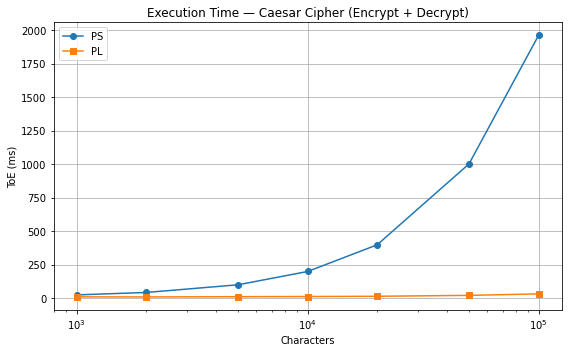

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(comparison["Characters"], comparison["ToE_PS_ms"], 'o-', label='PS')
plt.plot(comparison["Characters"], comparison["ToE_PL_ms"], 's-', label='PL')
plt.grid(True)
plt.xscale("log", base=10)
plt.xlabel("Characters")
plt.ylabel("ToE (ms)")
plt.title("Execution Time — Caesar Cipher (Encrypt + Decrypt)")
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_caesar_ToE.png", dpi=300)


**Comentario:** curva de tiempo total (cifrado + descifrado) en función del tamaño del mensaje, en escala logarítmica base 10 (a diferencia de la base 2 usada en el Experimento N° 2 para tamaños de bloque en potencias de dos, aquí `message_sizes` no sigue esa progresión, §4.2).

---

#### Celda C3 — Figura 2: Throughput PS vs PL

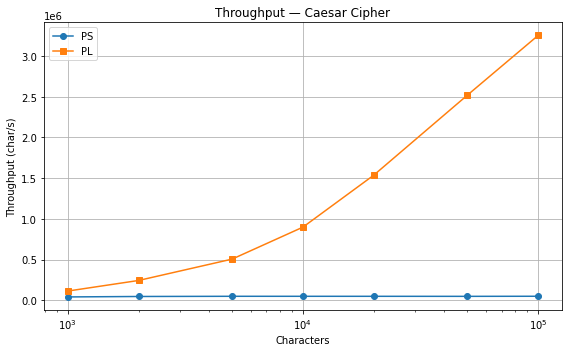

In [16]:
plt.figure(figsize=(8,5))
plt.plot(comparison["Characters"], comparison["Throughput_PS_char_s"], 'o-', label='PS')
plt.plot(comparison["Characters"], comparison["Throughput_PL_char_s"], 's-', label='PL')
plt.grid(True)
plt.xscale("log", base=10)
plt.xlabel("Characters")
plt.ylabel("Throughput (char/s)")
plt.title("Throughput — Caesar Cipher")
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_caesar_Throughput.png", dpi=300)

**Comentario:** contraparte directa de la Figura 1, expresada como tasa de procesamiento (caracteres/segundo) — permite visualizar a partir de qué tamaño de mensaje el *throughput* de PL supera al de PS.

---

#### Celda C4 — Figura 3: Speedup de hardware

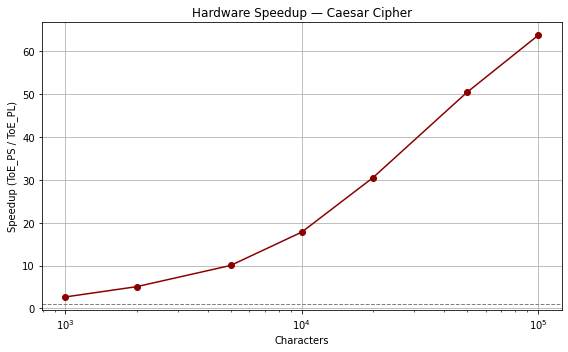


Todas las figuras fueron guardadas en:
 benchmark_caesar_ToE.png
 benchmark_caesar_Throughput.png
 benchmark_caesar_Speedup.png


In [17]:
plt.figure(figsize=(8,5))
plt.plot(comparison["Characters"], comparison["Speedup"], 'o-', color='darkred')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.grid(True)
plt.xscale("log", base=10)
plt.xlabel("Characters")
plt.ylabel("Speedup (ToE_PS / ToE_PL)")
plt.title("Hardware Speedup — Caesar Cipher")
plt.tight_layout()
plt.savefig("benchmark_caesar_Speedup.png", dpi=300)

plt.show()

print()
print("Todas las figuras fueron guardadas en:")
print(" benchmark_caesar_ToE.png")
print(" benchmark_caesar_Throughput.png")
print(" benchmark_caesar_Speedup.png")


**Comentario:** curva de síntesis de desempeño con una línea de referencia horizontal en `Speedup = 1` (paridad PS/PL), que facilita identificar visualmente el **punto de cruce** (*break-even*) a partir del cual PL se vuelve ventajoso. A diferencia del Experimento N° 2 (donde el *speedup* era prácticamente monótono creciente), aquí se espera que el *overhead* de re-arranque por *chunk* (§3.2) module la forma de esta curva de manera no trivial para mensajes que requieren múltiples fragmentos DMA.

---

### 6.4 Bloque D — Comunicación inalámbrica LoRA NO encriptada 
> **Programa de testeo de funcionamiento entre los módulo LoRa.** 


In [ ]:
# "Code para COMUNICACIÓN INALAMBRICA NO ENCRIPTADA ENTRE DOS MÓDULOS LORA"
# ==========================================================
# CLASE LoraModule - Control de módulos LoRa vía PYNQ
# (AXI GPIO para modo M1/M0 + AXI UART Lite para datos)
# ==========================================================
# Cada instancia representa UN módulo LoRa físico (con su
# propio bloque GPIO de control y su propio bloque UART).
# Para comunicación bidireccional se crean dos instancias
# (una para TX, otra para RX) — ver ejemplo de uso al final.
# ==========================================================

from pynq import Overlay, Clocks, MMIO
import time


class LoraModule:

    # ------------------------------------------------------
    # CONSTANTES DE CLASE (compartidas por todas las instancias)
    # ------------------------------------------------------

    # --- Modos de operación (bits M1, M0 vía AXI GPIO) ---
    #   M1 M0 | Modo
    #   0  0  | Transparente
    #   0  1  | Wake-Up
    #   1  0  | Power Saving
    #   1  1  | Sleep / Configuration
    MODE_TRANSPARENT = 0b00
    MODE_WAKEUP      = 0b01
    MODE_POWER_SAVE  = 0b10
    MODE_SLEEP       = 0b11

    MODOS_NOMBRE = {
        MODE_TRANSPARENT: "TRANSPARENT",
        MODE_WAKEUP:      "WAKEUP",
        MODE_POWER_SAVE:  "POWER_SAVE",
        MODE_SLEEP:       "SLEEP",
    }

    # --- Registros AXI GPIO ---
    GPIO_DATA = 0x00

    # --- Registros AXI UART Lite ---
    RX_FIFO = 0x00
    TX_FIFO = 0x04
    STATUS  = 0x08

    TX_FULL  = 0x08   # bit de estado: FIFO de TX llena
    RX_VALID = 0x01   # bit de estado: byte disponible en RX

    # --- Protocolo de framing propio ---
    PREAMBLE = b'\xAA\x55'

    # ------------------------------------------------------
    # CONSTRUCTOR
    # ------------------------------------------------------
    def __init__(self, name, gpio_base, uart_base, axi_range=0x1000):
        """
        Parámetros:
            name      : nombre identificador del módulo (para logs), ej. "LoRa1"
            gpio_base : dirección base del AXI GPIO de control de modo
            uart_base : dirección base del AXI UART Lite de datos
            axi_range : rango de direcciones AXI (por defecto 0x1000)
        """
        self.name = name
        self.gpio = MMIO(gpio_base, axi_range)
        self.uart = MMIO(uart_base, axi_range)
        self.mode = None  # se actualiza al llamar set_mode()

    # ------------------------------------------------------
    # CONTROL DE MODO (AXI GPIO)
    # ------------------------------------------------------
    def set_mode(self, mode):
        """Configura el modo de operación del módulo (M1/M0)."""
        self.gpio.write(self.GPIO_DATA, mode)
        self.mode = mode
        print(f"[{self.name}] M1={(mode >> 1) & 1} M0={mode & 1}")
        time.sleep(0.1)

    def get_mode(self):
        """Lee el modo actualmente configurado en el GPIO."""
        return self.gpio.read(self.GPIO_DATA) & 0x03

    def print_mode(self):
        """Imprime el modo actual en formato legible."""
        value = self.get_mode()
        print(f"{self.name}: {self.MODOS_NOMBRE[value]}")

    # ------------------------------------------------------
    # UART BÁSICO - ENVÍO / RECEPCIÓN DE BYTES
    # ------------------------------------------------------
    def _uart_send(self, data):
        """Envía una secuencia de bytes por UART, byte a byte."""
        for byte in data:
            while self.uart.read(self.STATUS) & self.TX_FULL:
                pass  # espera espacio en la FIFO de TX
            self.uart.write(self.TX_FIFO, byte)

    def _uart_read_byte(self, timeout=2):
        """Lee un solo byte del UART, con timeout en segundos."""
        start = time.time()
        while time.time() - start < timeout:
            if self.uart.read(self.STATUS) & self.RX_VALID:
                return self.uart.read(self.RX_FIFO) & 0xFF
        return None

    # ------------------------------------------------------
    # PROTOCOLO DE FRAMING
    # Formato: [0xAA][0x55][LEN_HIGH][LEN_LOW][PAYLOAD...]
    # ------------------------------------------------------
    def send_frame(self, payload):
        """Construye y transmite un frame completo."""
        frame = (
            self.PREAMBLE +
            len(payload).to_bytes(2, 'big') +
            payload
        )
        self._uart_send(frame)

    def receive_frame(self, timeout=5):
        """
        Recibe un frame completo:
          1) Sincroniza buscando el preámbulo 0xAA 0x55.
          2) Lee 2 bytes de longitud.
          3) Lee 'length' bytes de payload.
        Devuelve None si hay timeout en cualquier etapa.
        """
        start = time.time()
        state = 0

        # --- Sincronización con el preámbulo ---
        while time.time() - start < timeout:
            byte = self._uart_read_byte()

            if byte is None:
                continue

            if state == 0 and byte == 0xAA:
                state = 1
            elif state == 1 and byte == 0x55:
                break
            else:
                state = 0
        else:
            return None  # timeout sin encontrar preámbulo

        # --- Lectura de la longitud (2 bytes, big-endian) ---
        length_bytes = []
        for _ in range(2):
            b = self._uart_read_byte()
            if b is None:
                return None
            length_bytes.append(b)

        length = int.from_bytes(bytes(length_bytes), 'big')

        # --- Lectura del payload ---
        payload = bytearray()
        while len(payload) < length:
            b = self._uart_read_byte()
            if b is not None:
                payload.append(b)

        return bytes(payload)

    # ------------------------------------------------------
    # REPRESENTACIÓN LEGIBLE (debug / print directo del objeto)
    # ------------------------------------------------------
    def __repr__(self):
        modo = self.MODOS_NOMBRE.get(self.mode, "DESCONOCIDO")
        return f"<LoraModule '{self.name}' modo={modo}>"


# ==========================================================
# EJEMPLO BÁSICO DE USO DE LA CLASE LORA
# ==========================================================
if __name__ == "__main__":

    # ----------------------------------------------------
    # 1. Cargar overlay y configurar reloj del PL
    # ----------------------------------------------------
    print("fclk0_mhz antes:", Clocks.fclk0_mhz)
    ol = Overlay("design_1.bit") #puedes usar design_2 también.
    Clocks.fclk0_mhz = 100
    print("fclk0_mhz después:", Clocks.fclk0_mhz)
    print("IPs disponibles:", list(ol.ip_dict.keys()))

    # ----------------------------------------------------
    # 2. Direcciones AXI (según Address Editor de Vivado)
    # ----------------------------------------------------
    CONFIG_LORA1_BASE = 0x41200000
    CONFIG_LORA2_BASE = 0x41210000
    UART_LORA1_BASE   = 0x42C00000
    UART_LORA2_BASE   = 0x42C10000

    # ----------------------------------------------------
    # 3. Crear las instancias (una por módulo físico)
    # ----------------------------------------------------
    lora1 = LoraModule(
        name="LoRa1",
        gpio_base=CONFIG_LORA1_BASE,
        uart_base=UART_LORA1_BASE
    )
    lora2 = LoraModule(
        name="LoRa2",
        gpio_base=CONFIG_LORA2_BASE,
        uart_base=UART_LORA2_BASE
    )

    # ----------------------------------------------------
    # 4. Poner ambos en modo transparente
    # ----------------------------------------------------
    lora1.set_mode(LoraModule.MODE_TRANSPARENT)
    lora2.set_mode(LoraModule.MODE_TRANSPARENT)
    print("\nLoRa1 y LoRa2 listos para transmitir.\n")

    # ----------------------------------------------------
    # 5. Prueba básica: enviar un mensaje de texto
    # ----------------------------------------------------
    mensaje = b"Hola desde PYNQ 123"
    
    print("Transmitiendo...")
    lora1.send_frame(mensaje)

    print("Esperando respuesta...")
    data = lora2.receive_frame(timeout=10)

    if data is None:
        print("No se recibieron datos")
    else:
        print("Recibido:", data)
        print(data.decode(errors="ignore"))

    # ----------------------------------------------------
    # 6. Prueba con payload más largo (100 bytes)
    # ----------------------------------------------------
    mensaje_largo = b'A' * 100
    lora1.send_frame(mensaje_largo)
    data_largo = lora2.receive_frame(timeout=10)

    print("\nTX:", len(mensaje_largo))
    print("RX:", len(data_largo) if data_largo else 0)
    print("Correcto:", mensaje_largo == data_largo)

    # ----------------------------------------------------
    # 7. Verificar cambio de modos
    # ----------------------------------------------------
    lora1.set_mode(LoraModule.MODE_SLEEP)
    lora1.print_mode()

    lora1.set_mode(LoraModule.MODE_TRANSPARENT)
    lora1.print_mode()

    # ----------------------------------------------------
    # 8. Inspección rápida de los objetos
    # ----------------------------------------------------
    print(lora1)
    print(lora2)


---

### 6.5 Bloque E — Comunicación inalámbrica encriptada con cifrado César PS vs PL (LoRa)

> **Espacio reservado para el código que el estudiante incorporará.** Esta sección implementa la comunicación descrita teóricamente en §3.4: el mensaje cifrado (obtenido indistintamente del Bloque A o del Bloque B) se transmite entre dos nodos mediante un enlace LoRa, y se mide el tiempo total del enlace (`T_link`, §2.3) para ambos escenarios (cifrado en PS y cifrado en PL). Insertar aquí las celdas correspondientes (configuración del módulo LoRa, funciones de transmisión/recepción, y el bucle de medición de `T_link`), siguiendo el mismo formato de "Celda + Comentario" usado en §6.1–6.3.

In [ ]:

# ==========================================================
# PASO 1 - CONFIGURAR LOS MÓDULOS LORA
# ==========================================================


# ----------------------------------------------------
# 1. Cargar overlay y configurar reloj del PL
# ----------------------------------------------------
print("fclk0_mhz antes:", Clocks.fclk0_mhz)
ol = Overlay("design_2.bit")
Clocks.fclk0_mhz = 100
print("fclk0_mhz después:", Clocks.fclk0_mhz)
print("IPs disponibles:", list(ol.ip_dict.keys()))

# ----------------------------------------------------
# 2. Direcciones AXI de los Módulos Lora (según Address Editor de Vivado)
# ----------------------------------------------------
CONFIG_LORA1_BASE = 0x41200000
CONFIG_LORA2_BASE = 0x41210000
UART_LORA1_BASE   = 0x42C00000
UART_LORA2_BASE   = 0x42C10000

# ----------------------------------------------------
# 3. Crear las instancias (una por módulo físico)
# ----------------------------------------------------
lora1 = LoraModule(
    name="LoRa1",
    gpio_base=CONFIG_LORA1_BASE,
    uart_base=UART_LORA1_BASE
)
lora2 = LoraModule(
    name="LoRa2",
    gpio_base=CONFIG_LORA2_BASE,
    uart_base=UART_LORA2_BASE
)

# ----------------------------------------------------
# 4. Poner ambos en modo transparente
# ----------------------------------------------------
lora1.set_mode(LoraModule.MODE_TRANSPARENT)
lora2.set_mode(LoraModule.MODE_TRANSPARENT)
print("\nLoRa1 y LoRa2 listos para transmitir.\n")


# ==========================================================
# PASO 2 - ENCRIPTAR POR CPU LA COMUNICACIÓN INALÁMBRICA
# ENTRE LOS DOS MÓDULOS LORA (con medición de tiempos)
# ==========================================================

import time

SHIFT = 5
DIRECTION = "RIGHT"

cipher_cpu = CaesarCipher(shift=SHIFT, direction=DIRECTION)
mensaje_original = "HELLO FROM PYNQ"
print("=" * 60)
print(" CIFRADO CPU + LoRa ".center(60, "="))
print("=" * 60)
print(f"{'Cifrador utilizado':<22}: CaesarCipher")
print(f"{'Texto plano':<22}: {mensaje_original}")
print(f"{'Shift':<22}: {SHIFT}")
print(f"{'Direction':<22}: {DIRECTION}")
print("-" * 60)

# ----------------------------------------------------------
# 1. CIFRADO EN CPU (con medición de tiempo)
# ----------------------------------------------------------
t0 = time.perf_counter_ns()
mensaje_cifrado = cipher_cpu.encrypt(mensaje_original)
t1 = time.perf_counter_ns()
encrypt_ms = (t1 - t0) / 1e6

print(f"{'Texto cifrado':<22}: {mensaje_cifrado}")
print(f"{'Tiempo de cifrado':<22}: {encrypt_ms:.3f} ms")
print("-" * 60)

# ----------------------------------------------------------
# 2. TRANSMISIÓN POR LoRa1 -> LoRa2 (con medición de tiempo)
# ----------------------------------------------------------
payload = mensaje_cifrado.encode('ascii')

print("Transmitiendo por LoRa1...")
t2 = time.perf_counter_ns()
lora1.send_frame(payload)

print("Esperando recepción en LoRa2...")
payload_recibido = lora2.receive_frame(timeout=10)
t3 = time.perf_counter_ns()
lora_ms = (t3 - t2) / 1e6

if payload_recibido is None:
    print("-" * 60)
    print("ERROR: no se recibieron datos por LoRa")
    print("=" * 60)
else:
    texto_recibido_cifrado = payload_recibido.decode('ascii', errors='ignore')

    print(f"{'Recibido (cifrado)':<22}: {texto_recibido_cifrado}")
    print(f"{'Tiempo LoRa (TX+RX)':<22}: {lora_ms:.3f} ms")
    print("-" * 60)

    # ------------------------------------------------------
    # 3. DESCIFRADO EN CPU (con medición de tiempo)
    # ------------------------------------------------------
    t4 = time.perf_counter_ns()
    mensaje_descifrado = cipher_cpu.decrypt(texto_recibido_cifrado)
    t5 = time.perf_counter_ns()
    decrypt_ms = (t5 - t4) / 1e6

    total_ms = (t5 - t0) / 1e6
    correcto = mensaje_descifrado == mensaje_original

    print(f"{'Texto descifrado':<22}: {mensaje_descifrado}")
    print(f"{'Tiempo de descifrado':<22}: {decrypt_ms:.3f} ms")
    print("=" * 60)
    print(" RESUMEN ".center(60, "="))
    print("=" * 60)
    print(f"{'Tiempo cifrado':<22}: {encrypt_ms:>10.3f} ms")
    print(f"{'Tiempo LoRa':<22}: {lora_ms:>10.3f} ms")
    print(f"{'Tiempo descifrado':<22}: {decrypt_ms:>10.3f} ms")
    print("-" * 60)
    print(f"{'Tiempo total':<22}: {total_ms:>10.3f} ms")
    print(f"{'Coincide con original':<22}: {'✔ SÍ' if correcto else '✘ NO'}")
    print("=" * 60)

# ==========================================================
# PASO 3 - ENCRIPTAR POR FPGA LA COMUNICACIÓN INALÁMBRICA
# ENTRE LOS DOS MÓDULOS LORA (con medición de tiempos)
# ==========================================================

import time

# ----------------------------------------------------------
# Crear el objeto (reutiliza el overlay ya cargado)
# ----------------------------------------------------------
caesar = CaesarFPGA(ol)

KEY_FPGA = 3
DIRECTION_FPGA = CaesarFPGA.RIGHT
mensaje_original_fpga = "HELLO FROM PYNQ"
print("=" * 60)
print(" CIFRADO FPGA + LoRa ".center(60, "="))
print("=" * 60)
print(f"{'IP utilizado':<22}: {caesar}")
print(f"{'Texto plano':<22}: {mensaje_original_fpga}")
print(f"{'Key':<22}: {KEY_FPGA}")
print(f"{'Direction':<22}: {'RIGHT' if DIRECTION_FPGA == CaesarFPGA.RIGHT else 'LEFT'}")
print("-" * 60)

# ----------------------------------------------------------
# 1. CIFRADO EN FPGA (con medición de tiempo)
# ----------------------------------------------------------
t0 = time.perf_counter_ns()
mensaje_cifrado_fpga = caesar.encrypt(
    mensaje_original_fpga,
    key=KEY_FPGA,
    direction=DIRECTION_FPGA
)
t1 = time.perf_counter_ns()
encrypt_ms = (t1 - t0) / 1e6

print(f"{'Texto cifrado':<22}: {mensaje_cifrado_fpga}")
print(f"{'Tiempo de cifrado':<22}: {encrypt_ms:.3f} ms")
print("-" * 60)

# ----------------------------------------------------------
# 2. TRANSMISIÓN POR LoRa1 -> LoRa2 (con medición de tiempo)
# ----------------------------------------------------------
payload_fpga = mensaje_cifrado_fpga.encode('ascii')

print("Transmitiendo por LoRa1...")
t2 = time.perf_counter_ns()
lora1.send_frame(payload_fpga)

print("Esperando recepción en LoRa2...")
payload_recibido_fpga = lora2.receive_frame(timeout=10)
t3 = time.perf_counter_ns()
lora_ms = (t3 - t2) / 1e6

if payload_recibido_fpga is None:
    print("-" * 60)
    print("ERROR: no se recibieron datos por LoRa")
    print("=" * 60)
else:
    texto_recibido_cifrado_fpga = payload_recibido_fpga.decode('ascii', errors='ignore')

    print(f"{'Recibido (cifrado)':<22}: {texto_recibido_cifrado_fpga}")
    print(f"{'Tiempo LoRa (TX+RX)':<22}: {lora_ms:.3f} ms")
    print("-" * 60)

    # ------------------------------------------------------
    # 3. DESCIFRADO EN FPGA (con medición de tiempo)
    # ------------------------------------------------------
    t4 = time.perf_counter_ns()
    mensaje_descifrado_fpga = caesar.decrypt(
        texto_recibido_cifrado_fpga,
        key=KEY_FPGA,
        direction=DIRECTION_FPGA
    )
    t5 = time.perf_counter_ns()
    decrypt_ms = (t5 - t4) / 1e6

    total_ms = (t5 - t0) / 1e6
    correcto = mensaje_descifrado_fpga == mensaje_original_fpga

    print(f"{'Texto descifrado':<22}: {mensaje_descifrado_fpga}")
    print(f"{'Tiempo de descifrado':<22}: {decrypt_ms:.3f} ms")
    print("=" * 60)
    print(" RESUMEN ".center(60, "="))
    print("=" * 60)
    print(f"{'Tiempo cifrado':<22}: {encrypt_ms:>10.3f} ms")
    print(f"{'Tiempo LoRa':<22}: {lora_ms:>10.3f} ms")
    print(f"{'Tiempo descifrado':<22}: {decrypt_ms:>10.3f} ms")
    print("-" * 60)
    print(f"{'Tiempo total':<22}: {total_ms:>10.3f} ms")
    print(f"{'Coincide con original':<22}: {'✔ SÍ' if correcto else '✘ NO'}")
    print("=" * 60)


**Comentario:** este bloque queda intencionalmente en blanco para que el estudiante integre el *driver* específico del módulo LoRa disponible en el laboratorio (p. ej. por UART AT-commands o por SPI directo a un transceptor SX1276). Se recomienda mantener la misma estructura de reporte usada en los bloques anteriores (`DataFrame` con columnas `Characters`, `T_cifrado`, `T_LoRa_TX`, `T_LoRa_RX`, `T_descifrado`, `T_link_total`, `Success`) para que la sección 7.1 pueda extenderse de forma consistente con estos nuevos resultados.

---

## 7. ANÁLISIS DE RESULTADOS

### 7.1 Tabla comparativa de desempeño y exactitud funcional

Completar con los valores medidos en el barrido (Bloque C, `comparison`):

| Characters | ToE PS (ms) | ToE PL (ms) | Throughput PS (char/s) | Throughput PL (char/s) | Speedup | Success PS | Success PL |
|---|---|---|---|---|---|---|---|
| 1 000 | | | | | | | |
| 2 000 | | | | | | | |
| 5 000 | | | | | | | |
| 10 000 | | | | | | | |
| 20 000 | | | | | | | |
| 50 000 | | | | | | | |
| 100 000 | | | | | | | |

Adjuntar las tres figuras generadas en el Bloque C: `benchmark_caesar_ToE.png`, `benchmark_caesar_Throughput.png`, `benchmark_caesar_Speedup.png`, así como las tablas nativas de cada bloque (`report`, `summary`, `report_fpga`, `summary_fpga`, `comparison`) y, cuando esté disponible, la tabla de resultados del Bloque D (§6.4).

### 7.2 Preguntas de análisis

1. ¿A partir de qué tamaño de mensaje el *speedup* de PL supera a PS? ¿Existen tamaños pequeños donde PS sea más rápido que PL? Relacione la respuesta con el *overhead* de configuración de registros (`_configure`) y, sobre todo, con el **re-arranque de `ap_start` en cada *chunk*** (§3.2), que no tiene equivalente en el Experimento N° 2.
2. Calcule el número de *chunks* necesarios para el mensaje de 100 000 caracteres dado el `chunk_words` reportado por `CaesarFPGA.__repr__` (Celda B4). ¿Cómo esperaría que cambiara la curva de *speedup* (Celda C4) si `chunk_words` fuera el doble? Justifique en términos del número de *round-trips* DMA + `ap_start`/`ap_done` por mensaje.
3. Compare la naturaleza de la validación funcional de este experimento (`Success`, booleana y exacta, §3.3) con el RMSE del Experimento N° 2 (continuo y sujeto a cuantización). ¿Por qué un cifrado como el César no admite una noción de "error pequeño aceptable"?
4. El código actual mide `Encrypt_ns`/`Decrypt_ns` como el tiempo total de la llamada a `encrypt`/`decrypt`, que en PL incluye empaquetado, *chunking*, configuración de registros y todas las transferencias DMA. Proponga una modificación para medir por separado: (a) el tiempo de empaquetado a `bytes`/`uint64`, (b) el tiempo de configuración de registros (`_configure`), (c) el tiempo agregado de todas las transferencias DMA, y (d) el tiempo de espera de `ap_done` (`_wait_done`). ¿Cuál de estos cuatro esperaría que domine a tamaños de mensaje grandes? ¿Y a tamaños pequeños?
5. El cifrado César es criptográficamente inseguro (26 claves posibles). Discuta por qué, aun así, es un caso de estudio válido para este laboratorio, y qué cambiaría en la arquitectura del IP (§3.2) si se reemplazara por un algoritmo criptográficamente robusto (p. ej. AES), en términos de complejidad del *pipeline* HLS y de recursos DSP/BRAM.
6. Para el Bloque D (§6.4): si `T_LoRa(payload)` no depende de si el cifrado se hizo en PS o en PL (§3.4), ¿bajo qué condición de tamaño de mensaje el *speedup* de cómputo (Bloque C) tendría un impacto **perceptible** sobre `T_link_total`, y bajo cuál sería **despreciable** frente al tiempo en el aire del enlace LoRa? Relacione su respuesta con los valores típicos de *Time on Air* para distintos `SF` (§3.4).
7. ¿Qué ocurriría con la integridad (`Success`) del mensaje recibido si el nodo receptor del enlace LoRa (Bloque D) descifra con una clave (`KEY_REG`) distinta a la usada por el emisor? Relacione su respuesta con el mapa de registros de §4.3 y con las implicancias de un enlace inalámbrico donde la clave debe acordarse por un canal fuera de banda (*out-of-band key exchange*).

---

## 8. CONCLUSIONES ESPERADAS

Al finalizar el experimento, el estudiante debe ser capaz de:

- Diseñar un IP core con interfaz mixta (datos por AXI-Stream, control por AXI4-Lite) en Vitis HLS 2022 para un algoritmo de cifrado de flujo, e integrarlo en un *Block Design* de Vivado 2022 junto con un controlador DMA.
- Cuantificar, con datos propios, el *speedup* de un cifrador César al migrarlo del procesador a la lógica programable, incorporando explícitamente el efecto de la **fragmentación en *chunks*** cuando el tamaño de los datos excede el límite de una única transferencia DMA.
- Distinguir entre validación funcional **exacta** (integridad bit a bit, propia de algoritmos discretos como el cifrado César) y validación **numérica aproximada** (RMSE, propia de magnitudes continuas como la fase FM del Experimento N° 2).
- Integrar una capa de comunicación inalámbrica (LoRa) sobre un resultado computacional cifrado, relacionando los parámetros del enlace (SF, BW, CR, *Time on Air*) con el tiempo total de un sistema extremo a extremo.
- Identificar y proponer instrumentación adicional (medición desagregada de tiempos por *chunk*, por transferencia DMA y por configuración de registros) para aislar el *overhead* de control del tiempo de cómputo puro en el hardware.

---

## 9. REFERENCIAS SUGERIDAS

- Xilinx/AMD. *Vitis HLS User Guide (UG1399)* — interfaces `s_axilite`, `ap_ctrl_hs`, `axis`.
- Xilinx/AMD. *Zynq-7000 SoC Technical Reference Manual.*
- PYNQ Documentation. *pynq.Overlay, pynq.allocate, MMIO/registros de control.* (http://pynq.readthedocs.io)
- Semtech Corporation. *LoRa Modulation Basics (AN1200.22)* — factor de ensanchamiento, ancho de banda, tasa de codificación y *Time on Air*.
- Kahate, A. *Cryptography and Network Security* — cifrados clásicos de sustitución (César, Vigenère) y su vulnerabilidad criptoanalítica.
- Oppenheim, A. V.; Schafer, R. W. *Discrete-Time Signal Processing* — referencia general de procesamiento de flujo de datos en *pipeline*.

---

*Guía elaborada para el Banco de Pruebas de Procesamiento de Señales Electromagnéticas — Laboratorio Remoto PYNQ-Z2.*

## 10. ANEXOS
### 10.1 Anexo B - caesar64.h

In [ ]:
#ifndef CAESAR64_H
#define CAESAR64_H

#include <hls_stream.h>
#include <ap_axi_sdata.h>
#include <ap_int.h>

typedef ap_axiu<64,0,0,0> axis64_t;

void caesar64(
    hls::stream<axis64_t>& s_axis,
    hls::stream<axis64_t>& m_axis,
    unsigned int key,
    unsigned int direction,
    unsigned int mode
);

#endif


### 10.2 Anexo B - caesar64.cpp

In [ ]:
#include "caesar64.h"

static unsigned char process_char(
    unsigned char c,
    unsigned int key,
    unsigned int direction,
    unsigned int mode
)
{
#pragma HLS INLINE

    bool upper = (c >= 'A') && (c <= 'Z');
    bool lower = (c >= 'a') && (c <= 'z');

    if(!(upper || lower))
        return c;

    unsigned char base = upper ? 'A' : 'a';
    unsigned char idx  = c - base;

    if(mode == 0)
    {
        idx = (direction == 0) ?
              (idx + key) % 26 :
              (idx + 26 - key) % 26;
    }
    else
    {
        idx = (direction == 0) ?
              (idx + 26 - key) % 26 :
              (idx + key) % 26;
    }

    return idx + base;
}

void caesar64(
    hls::stream<axis64_t>& s_axis,
    hls::stream<axis64_t>& m_axis,
    unsigned int key,
    unsigned int direction,
    unsigned int mode
)
{
#pragma HLS INTERFACE axis port=s_axis
#pragma HLS INTERFACE axis port=m_axis

#pragma HLS INTERFACE s_axilite port=key
#pragma HLS INTERFACE s_axilite port=direction
#pragma HLS INTERFACE s_axilite port=mode
#pragma HLS INTERFACE s_axilite port=return

#pragma HLS PIPELINE II=1

PROCESS_STREAM:
    while(true)
    {
        axis64_t in_pkt = s_axis.read();

        axis64_t out_pkt;

        ap_uint<64> din  = in_pkt.data;
        ap_uint<64> dout = 0;

    PROCESS_BYTES:
        for(int i = 0; i < 8; i++)
        {
#pragma HLS UNROLL
            unsigned char c = din.range(8*i+7, 8*i);

            unsigned char r = process_char(
                c,
                key,
                direction,
                mode
            );

            dout.range(8*i+7, 8*i) = r;
        }

        out_pkt.data = dout;

        out_pkt.keep = in_pkt.keep;
        out_pkt.strb = in_pkt.strb;
        out_pkt.user = in_pkt.user;
        out_pkt.id   = in_pkt.id;
        out_pkt.dest = in_pkt.dest;
        out_pkt.last = in_pkt.last;

        m_axis.write(out_pkt);

        // ✔ FIN DE STREAM CONTROLADO POR TLAST
        if(in_pkt.last)
            return;
    }
}



### 10.3 Anexo C - test.cpp

In [ ]:
#include <iostream>
#include <cstring>

#include "caesar64.h"

using namespace std;

int main()
{
    hls::stream<axis64_t> in_stream;
    hls::stream<axis64_t> out_stream;

    const char msg[] =
        "HELLO FROM PYNQ FPGA";

    int len =
        strlen(msg);

    int words =
        (len + 7) / 8;

WRITE_INPUT:
    for(int w=0; w<words; w++)
    {
        axis64_t pkt;

        ap_uint<64> data = 0;

PACK:
        for(int b=0;b<8;b++)
        {
            int idx =
                w*8+b;

            unsigned char c =
                (idx < len)
                ? msg[idx]
                : 0;

            data.range(
                8*b+7,
                8*b
            ) = c;
        }

        pkt.data = data;

        pkt.keep = 0xFF;
        pkt.strb = 0xFF;

        pkt.last =
            (w == words-1);

        in_stream.write(pkt);
    }

    caesar64(
        in_stream,
        out_stream,
        3,
        0,
        0
    );

    cout << "Encrypted:" << endl;

READ_OUTPUT:
    while(!out_stream.empty())
    {
        axis64_t pkt =
            out_stream.read();

        ap_uint<64> d =
            pkt.data;

        for(int i=0;i<8;i++)
        {
            char c =
                d.range(
                    8*i+7,
                    8*i
                );

            if(c != 0)
                cout << c;
        }

        if(pkt.last)
            break;
    }

    cout << endl;

    return 0;
}
